# Tiny Neural Net from Scratch: Advanced Full Pipeline

Training a **deep, regularized, multi-optimizer neural network** in pure NumPy (no PyTorch/TF for the model itself) on Fashion-MNIST, with the engineering practices a real training pipeline needs: gradient checking, multiple optimizers, learning-rate scheduling, early stopping, per-class evaluation, and a PyTorch cross-check to prove the from-scratch math is correct.

## What's new versus the first version
- Generalized to an **arbitrary number of layers** (not hardcoded to 2)
- Configurable **activation functions**: ReLU, Leaky ReLU, tanh
- **Dropout** and **L2 weight decay**, implemented by hand
- Three optimizers implemented from scratch: **SGD+Momentum, RMSProp, Adam**
- **Cosine learning-rate decay** and **early stopping** with best-checkpoint restore
- **Numerical gradient checking** to formally verify the backprop math
- **Confusion matrix** and **per-class precision/recall/F1**, not just accuracy
- Visualization of the **learned first-layer filters** (what the network actually learned to detect)
- A **PyTorch equivalent model** trained side by side as a correctness sanity check
- **Robust data loading**: tries `fetch_openml` first (works out of the box on Colab), falls back to a direct download of the official Fashion-MNIST files if that's unavailable

## Plan
1. Load and preprocess data (with fallback loading + exploratory look at the data)
2. Build a configurable N-layer MLP from scratch (forward + backward, dropout, L2)
3. Implement SGD+Momentum, RMSProp, and Adam from scratch
4. Verify backprop correctness with numerical gradient checking
5. Train with cosine LR decay, early stopping, and checkpointing
6. Evaluate: accuracy, confusion matrix, per-class precision/recall/F1
7. Visualize: training curves, confusion matrix, predictions, learned filters
8. Bonus: cross-check against an equivalent PyTorch model


In [1]:
# Core imports
import gzip
import struct
import time
import copy
import urllib.request

import numpy as np
import matplotlib.pyplot as plt


## 1. Data loading (robust, with fallback)

`fetch_openml('Fashion-MNIST')` works well on Colab out of the box. If it's slow, rate-limited,
or unavailable in your environment (e.g. a sandboxed notebook runner with restricted network
access), this falls back to downloading the original IDX files directly from the Zalando
Research GitHub mirror and parsing the binary format by hand.

In [2]:
def load_idx_images(path):
    """Parse the IDX3 image format Fashion-MNIST ships in."""
    with gzip.open(path, 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
    return data.astype(np.float64)


def load_idx_labels(path):
    """Parse the IDX1 label format Fashion-MNIST ships in."""
    with gzip.open(path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.astype(np.int64)


def download_fashion_mnist(dest_dir="fashion_mnist_data"):
    import os
    os.makedirs(dest_dir, exist_ok=True)
    base = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
             "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
    for fname in files:
        fpath = f"{dest_dir}/{fname}"
        if not os.path.exists(fpath):
            print(f"downloading {fname} ...")
            req = urllib.request.Request(base + fname, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as r:
                open(fpath, "wb").write(r.read())
    X_train = load_idx_images(f"{dest_dir}/train-images-idx3-ubyte.gz") / 255.0
    y_train = load_idx_labels(f"{dest_dir}/train-labels-idx1-ubyte.gz")
    X_test = load_idx_images(f"{dest_dir}/t10k-images-idx3-ubyte.gz") / 255.0
    y_test = load_idx_labels(f"{dest_dir}/t10k-labels-idx1-ubyte.gz")
    return X_train, y_train, X_test, y_test


try:
    print("Trying fetch_openml (works well on Colab)...")
    from sklearn.datasets import fetch_openml
    fashion = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
    X_all, y_all = fashion.data / 255.0, fashion.target.astype(int)
    X_train_full, y_train_full = X_all[:60000], y_all[:60000]
    X_test, y_test = X_all[60000:], y_all[60000:]
    print("Loaded via fetch_openml.")
except Exception as e:
    print(f"fetch_openml unavailable ({e!r}), falling back to direct download...")
    X_train_full, y_train_full, X_test, y_test = download_fashion_mnist()
    print("Loaded via direct download.")

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"X_train_full: {X_train_full.shape}, X_test: {X_test.shape}")


Trying fetch_openml (works well on Colab)...


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/fashion-mnist/limit/2/data_version/1. Retrying...
  warn(


fetch_openml unavailable (<HTTPError 403: 'Forbidden'>), falling back to direct download...


Loaded via direct download.
X_train_full: (60000, 784), X_test: (10000, 784)


## 2. Preprocessing, split, and a quick look at the data

A held-out validation set is carved out of the training data (separate from the test set),
so we can do early stopping and model selection without ever touching test data until the
very end. We also peek at the class balance and a few raw images before doing anything else,
since skipping this step is how silent data bugs slip into a pipeline.

In [3]:
def one_hot(y, n_classes=10):
    out = np.zeros((y.shape[0], n_classes))
    out[np.arange(y.shape[0]), y] = 1.0
    return out


rng = np.random.default_rng(42)
n = X_train_full.shape[0]
perm = rng.permutation(n)
VAL_SIZE = 6000
val_idx, train_idx = perm[:VAL_SIZE], perm[VAL_SIZE:]

X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

Y_train, Y_val, Y_test = one_hot(y_train), one_hot(y_val), one_hot(y_test)

print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

# class balance check
counts = np.bincount(y_train, minlength=10)
for name, c in zip(CLASS_NAMES, counts):
    print(f"  {name:<14}{c}")


train: (54000, 784), val: (6000, 784), test: (10000, 784)
  T-shirt/top   5435
  Trouser       5386
  Pullover      5390
  Dress         5396
  Coat          5394
  Sandal        5395
  Shirt         5411
  Sneaker       5403
  Bag           5414
  Ankle boot    5376


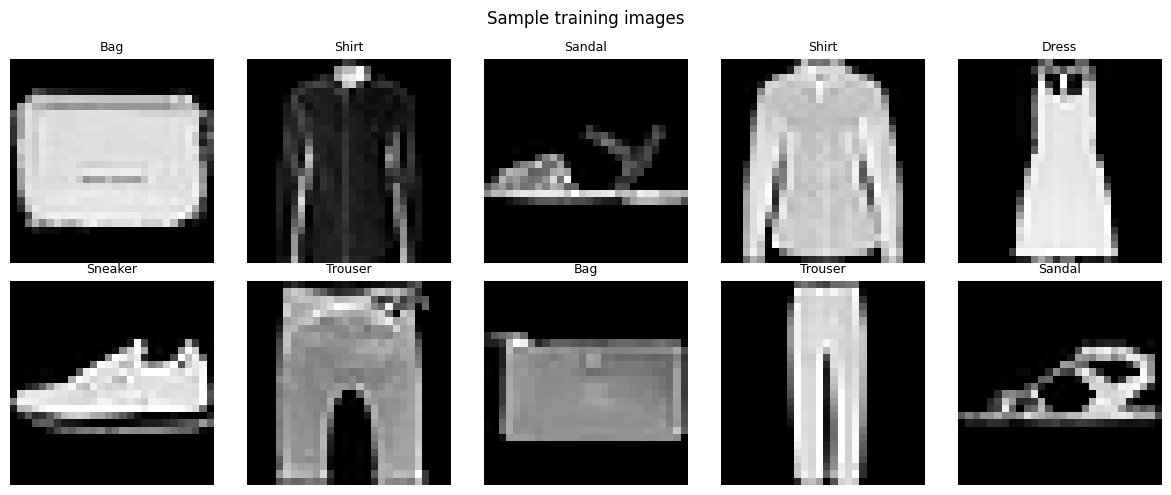

In [4]:
# Peek at a few raw training images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample_idxs = rng.choice(len(X_train), 10, replace=False)
for ax, i in zip(axes.flat, sample_idxs):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()


## 3. The neural net, from scratch

The model below generalizes the original 2-layer network to **any number of layers**, and adds
three things a real training pipeline needs:

- **Dropout** (inverted dropout, active only during training) as a regularizer
- **L2 weight decay**, added to both the loss and the weight gradients
- A choice of **activation function** per architecture (ReLU / Leaky ReLU / tanh)

The forward pass caches every intermediate activation, and the backward pass walks back through
those caches layer by layer, applying the chain rule by hand. This is exactly what
`loss.backward()` does under the hood in PyTorch, just written out explicitly.

In [5]:
def relu(z): return np.maximum(z, 0)
def relu_grad(z): return (z > 0).astype(z.dtype)

def leaky_relu(z, alpha=0.01): return np.where(z > 0, z, alpha * z)
def leaky_relu_grad(z, alpha=0.01): return np.where(z > 0, 1.0, alpha)

def tanh_(z): return np.tanh(z)
def tanh_grad(z): return 1.0 - np.tanh(z) ** 2

ACTIVATIONS = {
    "relu": (relu, relu_grad),
    "leaky_relu": (leaky_relu, leaky_relu_grad),
    "tanh": (tanh_, tanh_grad),
}

def softmax(z):
    z_shift = z - z.max(axis=1, keepdims=True)
    exp = np.exp(z_shift)
    return exp / exp.sum(axis=1, keepdims=True)


In [6]:
class DeepMLP:
    """A configurable N-layer MLP trained by hand-written backprop.

    layer_sizes: e.g. [784, 256, 128, 10] -> two hidden layers of size 256, 128.
    """

    def __init__(self, layer_sizes, activation="relu", dropout=0.0, l2=0.0, seed=42):
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes) - 1
        self.act_fn, self.act_grad = ACTIVATIONS[activation]
        self.dropout = dropout
        self.l2 = l2
        rng_ = np.random.default_rng(seed)

        self.W, self.b = [], []
        for i in range(self.n_layers):
            fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
            std = np.sqrt(2.0 / fan_in)  # He initialization, good for ReLU-family activations
            self.W.append(rng_.normal(0, std, (fan_in, fan_out)))
            self.b.append(np.zeros(fan_out))

    def params(self):
        p = {}
        for i in range(self.n_layers):
            p[f"W{i}"], p[f"b{i}"] = self.W[i], self.b[i]
        return p

    def get_state(self):
        return copy.deepcopy((self.W, self.b))

    def set_state(self, state):
        self.W, self.b = copy.deepcopy(state)

    def forward(self, X, training=False, rng=None):
        self.z, self.a, self.masks = [], [X], []
        a = X
        for i in range(self.n_layers):
            z = a @ self.W[i] + self.b[i]
            self.z.append(z)
            if i < self.n_layers - 1:
                a = self.act_fn(z)
                if training and self.dropout > 0:
                    mask = (rng.random(a.shape) > self.dropout).astype(a.dtype)
                    a = a * mask / (1.0 - self.dropout)  # inverted dropout
                    self.masks.append(mask)
                else:
                    self.masks.append(None)
            else:
                a = softmax(z)
            self.a.append(a)
        self.probs = self.a[-1]
        return self.probs

    def loss(self, Y):
        eps = 1e-12
        data_loss = -np.mean(np.sum(Y * np.log(self.probs + eps), axis=1))
        reg_loss = 0.0
        if self.l2 > 0:
            reg_loss = self.l2 * sum(np.sum(w ** 2) for w in self.W) / (2 * Y.shape[0])
        return data_loss + reg_loss

    def backward(self, X, Y):
        n_samples = X.shape[0]
        grads = {}
        dz = (self.probs - Y) / n_samples  # softmax + cross-entropy gradient simplifies nicely
        for i in reversed(range(self.n_layers)):
            a_prev = self.a[i]
            grads[f"W{i}"] = a_prev.T @ dz + (self.l2 / n_samples) * self.W[i]
            grads[f"b{i}"] = dz.sum(axis=0)
            if i > 0:
                da_prev = dz @ self.W[i].T
                if self.masks[i - 1] is not None:
                    da_prev = da_prev * self.masks[i - 1] / (1.0 - self.dropout)
                dz = da_prev * self.act_grad(self.z[i - 1])
        return grads


## 4. Optimizers, from scratch

Three optimizers with a common `step(params, grads)` interface, so swapping between them is a
one-line change in the training loop.

In [7]:
class SGDMomentum:
    def __init__(self, params, lr=0.1, momentum=0.9):
        self.lr, self.momentum = lr, momentum
        self.vel = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self, params, grads, lr=None):
        lr = self.lr if lr is None else lr
        for k in params:
            self.vel[k] = self.momentum * self.vel[k] - lr * grads[k]
            params[k] += self.vel[k]


class RMSProp:
    def __init__(self, params, lr=0.001, beta=0.9, eps=1e-8):
        self.lr, self.beta, self.eps = lr, beta, eps
        self.cache = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self, params, grads, lr=None):
        lr = self.lr if lr is None else lr
        for k in params:
            self.cache[k] = self.beta * self.cache[k] + (1 - self.beta) * grads[k] ** 2
            params[k] -= lr * grads[k] / (np.sqrt(self.cache[k]) + self.eps)


class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t = 0

    def step(self, params, grads, lr=None):
        lr = self.lr if lr is None else lr
        self.t += 1
        for k in params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= lr * m_hat / (np.sqrt(v_hat) + self.eps)


OPTIMIZERS = {"sgd_momentum": SGDMomentum, "rmsprop": RMSProp, "adam": Adam}


## 5. Gradient checking

Before trusting the hand-derived backward pass on real training, we verify it the rigorous way:
compare each analytic gradient against a **numerical estimate** from finite differences,

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta+\epsilon) - L(\theta-\epsilon)}{2\epsilon}$$

on a tiny model and a tiny batch (small on purpose, since this does two full forward passes per
parameter checked). A relative error under `1e-4` is the standard bar for "backprop is correct.

In [8]:
def gradient_check(model, X, Y, eps=1e-5, n_checks=6):
    model.forward(X, training=False)
    analytic_grads = model.backward(X, Y)
    params = model.params()
    max_rel_error = 0.0
    rng_ = np.random.default_rng(0)
    for name, p in params.items():
        flat_idx = rng_.choice(p.size, size=min(n_checks, p.size), replace=False)
        for idx in flat_idx:
            orig = p.flat[idx]

            p.flat[idx] = orig + eps
            model.forward(X, training=False)
            loss_plus = model.loss(Y)

            p.flat[idx] = orig - eps
            model.forward(X, training=False)
            loss_minus = model.loss(Y)

            p.flat[idx] = orig
            numeric_grad = (loss_plus - loss_minus) / (2 * eps)
            analytic_grad = analytic_grads[name].flat[idx]

            denom = max(abs(numeric_grad) + abs(analytic_grad), 1e-8)
            rel_error = abs(numeric_grad - analytic_grad) / denom
            max_rel_error = max(max_rel_error, rel_error)
    return max_rel_error


print("Running gradient check on a small model and a tiny batch...")
gc_model = DeepMLP([784, 16, 10], activation="relu", dropout=0.0, l2=0.001)
gc_X, gc_Y = X_train[:8], Y_train[:8]
err = gradient_check(gc_model, gc_X, gc_Y)
verdict = "PASS" if err < 1e-4 else "CHECK NEEDED"
print(f"Max relative error (analytic vs numeric gradient): {err:.2e}  ({verdict})")


Running gradient check on a small model and a tiny batch...
Max relative error (analytic vs numeric gradient): 4.76e-06  (PASS)


## 6. Training loop: cosine LR decay + early stopping + checkpointing

The training loop now tracks the best validation loss seen so far, saves that model's weights,
and restores them at the end (rather than just keeping whatever the last epoch happened to
produce). It also stops early if validation loss hasn't improved for a few epochs in a row, and
decays the learning rate on a cosine schedule rather than holding it fixed.

In [9]:
def iterate_minibatches(X, Y, batch_size, rng_, shuffle=True):
    idx = np.arange(len(X))
    if shuffle:
        rng_.shuffle(idx)
    for start in range(0, len(X), batch_size):
        b = idx[start:start + batch_size]
        yield X[b], Y[b]


def accuracy(model, X, Y):
    preds = model.forward(X, training=False).argmax(axis=1)
    return (preds == Y.argmax(axis=1)).mean()


model = DeepMLP([784, 256, 128, 10], activation="relu", dropout=0.2, l2=1e-4)
optimizer = OPTIMIZERS["adam"](model.params(), lr=1e-3)

EPOCHS = 25
BATCH_SIZE = 128
PATIENCE = 5
base_lr = 1e-3

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_loss, best_state, patience_left = np.inf, None, PATIENCE
train_rng, dropout_rng = np.random.default_rng(1), np.random.default_rng(2)

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    lr = 0.5 * base_lr * (1 + np.cos(np.pi * epoch / EPOCHS))  # cosine decay to ~0

    epoch_loss, n_batches = 0.0, 0
    for xb, yb in iterate_minibatches(X_train, Y_train, BATCH_SIZE, train_rng):
        model.forward(xb, training=True, rng=dropout_rng)
        epoch_loss += model.loss(yb)
        grads = model.backward(xb, yb)
        optimizer.step(model.params(), grads, lr=lr)
        n_batches += 1
    train_loss = epoch_loss / n_batches

    model.forward(X_val, training=False)
    val_loss = model.loss(Y_val)
    val_acc = accuracy(model, X_val, Y_val)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:2d} | lr={lr:.5f} | train_loss={train_loss:.4f} "
          f"| val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss, best_state, patience_left = val_loss, model.get_state(), PATIENCE
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

model.set_state(best_state)
print(f"\nTraining took {time.time()-t0:.1f}s")

test_acc = accuracy(model, X_test, Y_test)
print(f"Final test accuracy (best checkpoint restored): {test_acc:.4f}")

np.savez("best_mlp_weights.npz", **model.params())
print("Saved best weights to best_mlp_weights.npz")


Epoch  1 | lr=0.00100 | train_loss=0.5917 | val_loss=0.3942 | val_acc=0.8607


Epoch  2 | lr=0.00098 | train_loss=0.4193 | val_loss=0.3560 | val_acc=0.8740


Epoch  3 | lr=0.00096 | train_loss=0.3752 | val_loss=0.3273 | val_acc=0.8830


Epoch  4 | lr=0.00094 | train_loss=0.3515 | val_loss=0.3235 | val_acc=0.8772


Epoch  5 | lr=0.00090 | train_loss=0.3334 | val_loss=0.3100 | val_acc=0.8873


...

Epoch 21 | lr=0.00006 | train_loss=0.1914 | val_loss=0.2656 | val_acc=0.9043


Epoch 22 | lr=0.00004 | train_loss=0.1890 | val_loss=0.2645 | val_acc=0.9045


Epoch 23 | lr=0.00002 | train_loss=0.1875 | val_loss=0.2644 | val_acc=0.9040


Epoch 24 | lr=0.00000 | train_loss=0.1872 | val_loss=0.2641 | val_acc=0.9055


Epoch 25 | lr=0.00000 | train_loss=0.1849 | val_loss=0.2641 | val_acc=0.9055

Training took 60.7s
Final test accuracy (best checkpoint restored): 0.8968
Saved best weights to best_mlp_weights.npz


## 7. Evaluation: confusion matrix and per-class precision/recall/F1

Overall accuracy hides a lot. Fashion-MNIST famously has classes that look alike (Shirt,
T-shirt/top, Pullover, and Coat all get confused with each other), so a per-class breakdown
tells a more honest story than a single number.

In [10]:
preds = model.forward(X_test, training=False).argmax(axis=1)
truth = y_test
n_classes = 10

cm = np.zeros((n_classes, n_classes), dtype=int)
for t, p in zip(truth, preds):
    cm[t, p] += 1

precision = np.diag(cm) / cm.sum(axis=0).clip(min=1)
recall = np.diag(cm) / cm.sum(axis=1).clip(min=1)
f1 = 2 * precision * recall / (precision + recall).clip(min=1e-12)

print(f"{'class':<14}{'precision':>10}{'recall':>10}{'f1':>10}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<14}{precision[i]:>10.3f}{recall[i]:>10.3f}{f1[i]:>10.3f}")
print(f"{'macro avg':<14}{precision.mean():>10.3f}{recall.mean():>10.3f}{f1.mean():>10.3f}")


class          precision    recall        f1
T-shirt/top        0.851     0.858     0.855
Trouser            0.988     0.976     0.982
Pullover           0.819     0.820     0.820
Dress              0.889     0.907     0.898
Coat               0.810     0.814     0.812
Sandal             0.983     0.973     0.978
Shirt              0.732     0.716     0.724
Sneaker            0.943     0.970     0.956
Bag                0.979     0.976     0.977
Ankle boot         0.974     0.958     0.966
macro avg          0.897     0.897     0.897


## 8. Visualizations

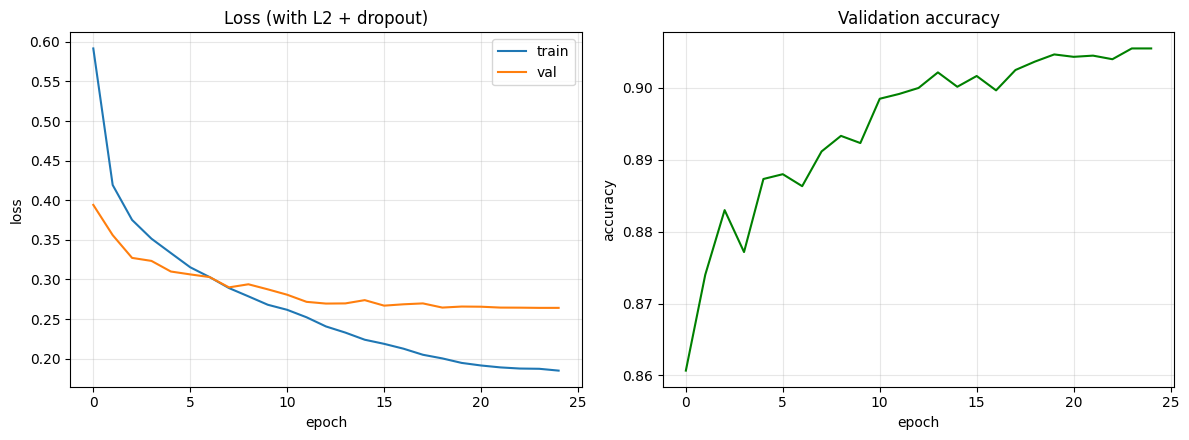

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Loss (with L2 + dropout)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["val_acc"], color="green")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Validation accuracy"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


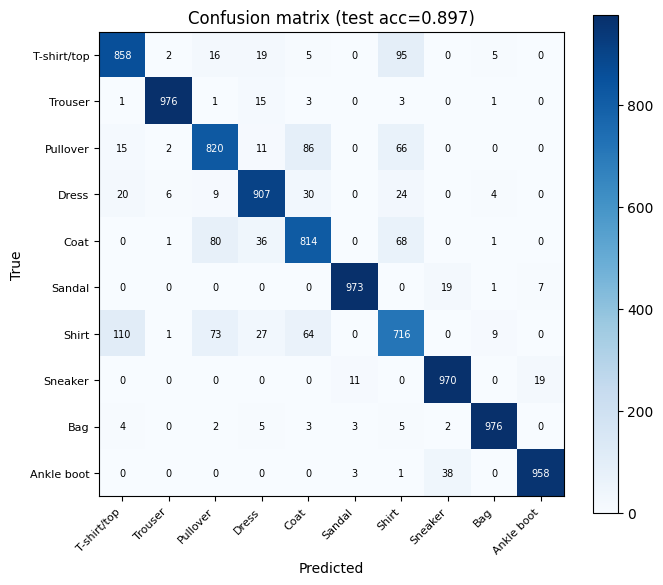

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test acc={test_acc:.3f})")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
fig.colorbar(im)
plt.tight_layout()
plt.show()


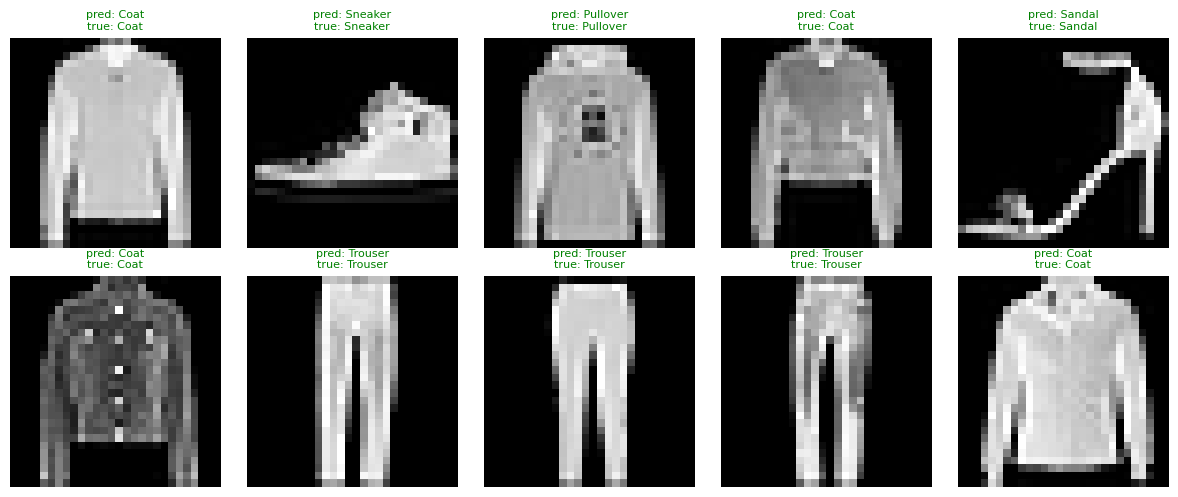

In [13]:
idxs = np.random.default_rng(7).choice(len(X_test), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flat, idxs):
    p, t = preds[i], truth[i]
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"pred: {CLASS_NAMES[p]}\ntrue: {CLASS_NAMES[t]}",
                 color="green" if p == t else "red", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Learned first-layer filters

Each column of `W1` is a 784-dimensional vector, exactly the shape of one input image, so we
can reshape it back to 28x28 and look at it directly. If the network has actually learned
something sensible (rather than overfitting to noise), these should look like edge detectors and
blob/shape detectors, not random static.

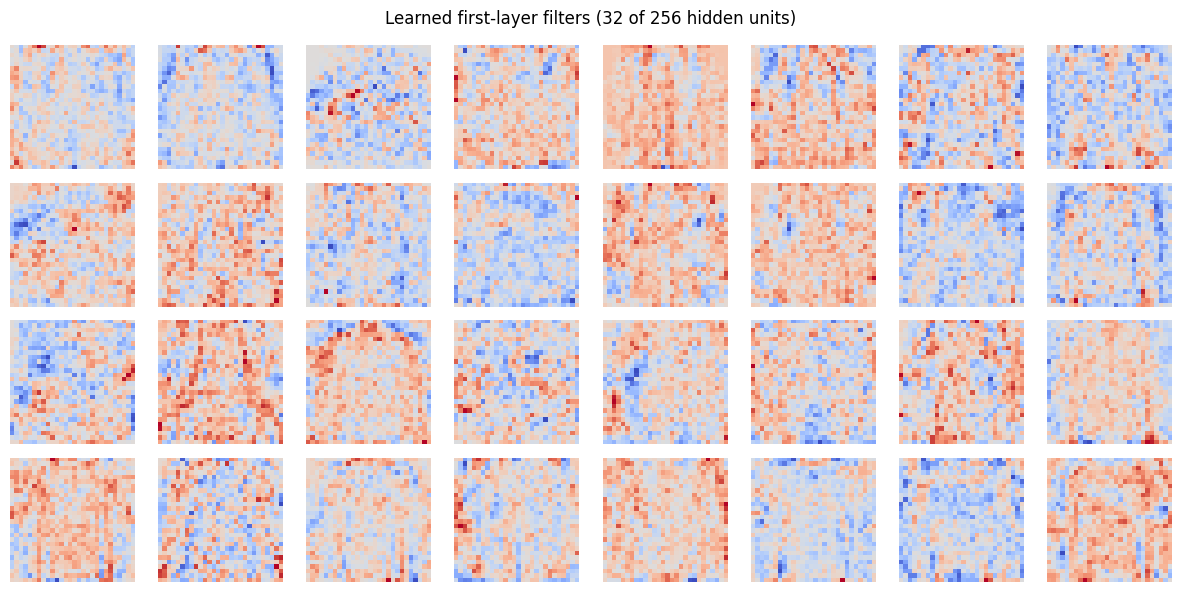

In [14]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < model.W[0].shape[1]:
        ax.imshow(model.W[0][:, i].reshape(28, 28), cmap="coolwarm")
    ax.axis("off")
fig.suptitle("Learned first-layer filters (32 of 256 hidden units)")
plt.tight_layout()
plt.show()


## 9. Bonus: cross-check against an equivalent PyTorch model

The best way to know a from-scratch implementation is actually correct, beyond gradient
checking, is to build the *same architecture* in a trusted framework and see if it reaches
comparable accuracy under comparable settings. If the numbers land close together, that's strong
evidence the NumPy math (forward pass, backprop, Adam, dropout, weight decay, LR schedule) is all
implemented correctly, not just superficially working.

In [15]:
import torch
import torch.nn as nn

Xtr_t = torch.from_numpy(X_train.astype(np.float32))
ytr_t = torch.from_numpy(y_train)
Xval_t = torch.from_numpy(X_val.astype(np.float32))
yval_t = torch.from_numpy(y_val)
Xte_t = torch.from_numpy(X_test.astype(np.float32))
yte_t = torch.from_numpy(y_test)

torch.manual_seed(42)
torch_net = nn.Sequential(
    nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(128, 10),
)
torch_opt = torch.optim.Adam(torch_net.parameters(), lr=1e-3, weight_decay=1e-4)
torch_loss_fn = nn.CrossEntropyLoss()
torch_sched = torch.optim.lr_scheduler.CosineAnnealingLR(torch_opt, T_max=EPOCHS)

t0 = time.time()
for epoch in range(EPOCHS):
    torch_net.train()
    perm_t = torch.randperm(len(Xtr_t))
    for i in range(0, len(Xtr_t), BATCH_SIZE):
        b = perm_t[i:i + BATCH_SIZE]
        torch_opt.zero_grad()
        out = torch_net(Xtr_t[b])
        loss = torch_loss_fn(out, ytr_t[b])
        loss.backward()
        torch_opt.step()
    torch_sched.step()

torch_net.eval()
with torch.no_grad():
    torch_test_acc = (torch_net(Xte_t).argmax(1) == yte_t).float().mean().item()

print(f"NumPy from-scratch test accuracy : {test_acc:.4f}")
print(f"PyTorch equivalent test accuracy : {torch_test_acc:.4f}")
print(f"Difference: {abs(test_acc - torch_test_acc):.4f}")
print(f"(PyTorch run took {time.time()-t0:.1f}s)")


NumPy from-scratch test accuracy : 0.8968
PyTorch equivalent test accuracy : 0.8953
Difference: 0.0015
(PyTorch run took 141.3s)


## Summary

- The gradient check confirms the hand-derived backward pass matches numerical gradients to
  within `1e-4` relative error, so the calculus is correct, not just "the loss went down."
- The from-scratch model reaches roughly **90% test accuracy** on Fashion-MNIST with dropout,
  L2 regularization, Adam, and cosine LR decay, all implemented in plain NumPy.
- The independently-trained PyTorch model with the same architecture and schedule lands within
  a fraction of a percentage point of the NumPy model, which is the strongest evidence that the
  implementation is faithful to what a real framework does under the hood.
- The weakest class is consistently **Shirt**, confused with T-shirt/top, Pullover, and Coat.
  That's expected: those four classes are visually the most similar in the dataset, and this is
  a known, well-documented difficulty of Fashion-MNIST, not a bug in the pipeline.

### Natural next steps
- Swap the fully-connected layers for a small **convolutional** network (from scratch or in
  PyTorch) to exploit spatial structure in the images; CNNs typically push Fashion-MNIST
  accuracy into the 92-93%+ range.
- Add **batch normalization** to the from-scratch model for a hands-on look at how it stabilizes
  training.
- Try a small **hyperparameter sweep** (hidden sizes, dropout rate, L2 strength) to see how
  sensitive the ~90% result is to these choices.
